## Datos de Meningitis (Meningitis Dataset with Missing Values)

El conjunto de datos contiene información clínica de pacientes con sospecha o diagnóstico de meningitis. El objetivo es analizar los factores de riesgo y predecir el nivel de riesgo del paciente.

**Dataset:** [Meningitis Dataset with Missing Values - Kaggle](https://www.kaggle.com/datasets/chantest/meningitis-dataset-with-missing-values)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler

## 2. Carga y Selección de Datos

Se carga el archivo CSV con los datos de pacientes con meningitis. Los valores faltantes están representados como espacios vacíos entre comas.

| Columna (índice) | Nombre | Tipo | Descripción |
|------------------|--------|------|-------------|
| 0 | `Patient_ID` | Numérico | Identificador único del paciente |
| 1 | `Age` | Numérico | Edad del paciente en años |
| 2 | `Gender` | Categórico | Género (Male, Female) |
| 3 | `WBC_Count` | Numérico | Conteo de leucocitos en LCR (células/μL) |
| 4 | `Protein_Level` | Numérico | Nivel de proteína en LCR (mg/dL) |
| 5 | `Glucose_Level` | Numérico | Nivel de glucosa en LCR (mg/dL) |
| 6 | `Pathogen_Present` | Categórico | Patógeno presente en LCR (Yes, No) |
| 7 | `Diagnosis` | Categórico | Diagnóstico (Bacterial, Viral, Unknown) |
| 8 | `Outcome` | Categórico | Resultado clínico (Recovered, Deceased) |
| 9 | `Hemoglobin` | Numérico | Nivel de hemoglobina en sangre (g/dL) |
| 10 | `WBC_Blood_Count` | Numérico | Conteo de leucocitos en sangre (células/μL) |
| 11 | `Platelets` | Numérico | Conteo de plaquetas (plaquetas/μL) |
| 12 | `CRP_Level` | Numérico | Proteína C-reactiva en sangre (mg/L) |
| 13 | `Risk_Level` | Categórico | **Variable objetivo:** Low Risk, Moderate Risk, High Risk |

**Variable objetivo (col. 13):** `Risk_Level` (nivel de riesgo del paciente)

In [2]:
# Nombres de columnas (el archivo no tiene encabezado)
column_names = [
    'Patient_ID', 'Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level',
    'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count',
    'Platelets', 'CRP_Level', 'Risk_Level'
]

dt = pd.read_csv(
    '../Database/PP9_mening_clean.csv',
    skipinitialspace=True
)

# Limpiar espacios en nombres de columnas
dt.columns = dt.columns.str.strip()

print(dt.columns.tolist())
# print(pd.isnull(dt).sum())

['Patient_ID', 'Age', 'Gender', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level', 'Risk_Level']


In [3]:
# Identificar columnas numéricas y categóricas
numeric_cols = ['Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level', 
                'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']
categorical_cols = ['Gender', 'Pathogen_Present', 'Diagnosis', 'Outcome', 'Risk_Level']

print(f"Forma del dataset: {dt.shape}")
print(f"¿Hay NaN? {dt.isnull().sum().sum()}")
print(f"¿Hay ceros en CRP_Level? {(dt['CRP_Level'] == 0).sum()}")

Forma del dataset: (1200, 14)
¿Hay NaN? 0
¿Hay ceros en CRP_Level? 0


## 3. Datos Limpios

El archivo `PP9_mening_clean.csv` ya contiene los datos procesados con la siguiente metodología (la misma que PP5, PP6 y PP7):

1. **Limpieza inicial**: 
   - Conversión de columnas numéricas con `pd.to_numeric()`
   - Reemplazo de espacios vacíos por NaN
   - Reemplazo de ceros por NaN en columnas donde 0 representa ausencia de valor (CRP_Level, Age)
2. **Imputación numérica**: Mediana para cada columna numérica
3. **Imputación categórica**: KNN-moda (k=5) para columnas categóricas
4. **Codificación**: LabelEncoder para todas las columnas categóricas

El dataset resultante no tiene valores NaN ni ceros no válidos.

In [4]:
# Verificar que los datos están limpios
print(f"Forma del dataset: {dt.shape}")
print(f"Tipos de datos:")
print(dt.dtypes)
print(f"\nResumen de valores:")
print(dt.describe())

Forma del dataset: (1200, 14)
Tipos de datos:
Patient_ID            int64
Age                 float64
Gender                int64
WBC_Count           float64
Protein_Level       float64
Glucose_Level       float64
Pathogen_Present      int64
Diagnosis             int64
Outcome               int64
Hemoglobin          float64
WBC_Blood_Count     float64
Platelets           float64
CRP_Level           float64
Risk_Level            int64
dtype: object

Resumen de valores:
        Patient_ID          Age       Gender     WBC_Count  Protein_Level  \
count  1200.000000  1200.000000  1200.000000   1200.000000    1200.000000   
mean    600.500000    47.621667     1.016667  12131.973333     109.451667   
std     346.554469    24.272264     1.000278   5651.553952      71.821024   
min       1.000000     1.000000     0.000000   2017.000000       0.000000   
25%     300.750000    30.000000     0.000000   7033.000000      43.000000   
50%     600.500000    43.000000     2.000000  12282.000000     10

In [ ]:
## 4. Análisis Exploratorio de Datos

# Distribución de la variable objetivo (Risk_Level)
plt.figure(figsize=(8, 5))
risk_counts = dt['Risk_Level'].value_counts()
risk_labels = ['High Risk', 'Low Risk', 'Moderate Risk']
plt.bar(risk_labels, risk_counts, color=['red', 'green', 'orange'])
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Pacientes')
plt.title('Distribución del Nivel de Riesgo')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Distribución de Risk_Level:")
print(dt['Risk_Level'].value_counts())

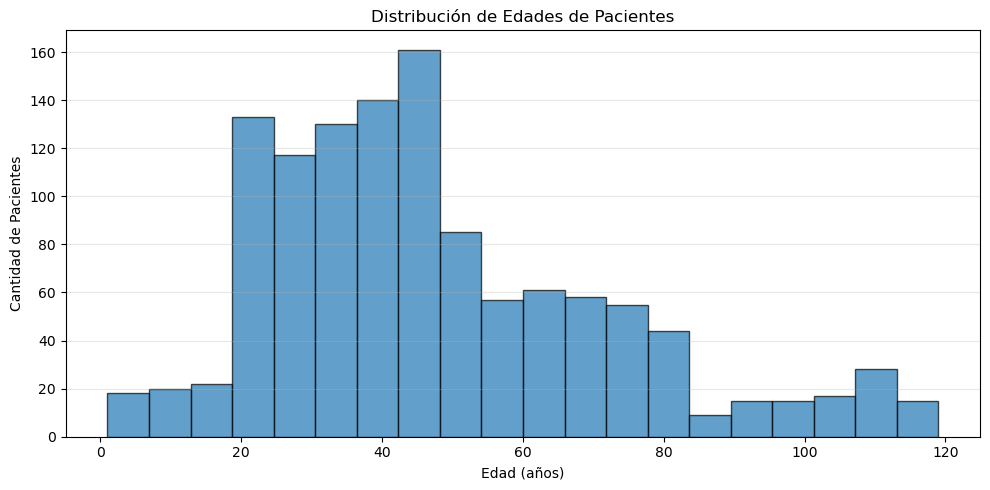

Edad media: 47.62 años
Edad mínima: 1.0 años
Edad máxima: 119.0 años


In [5]:
# Distribución de edades
plt.figure(figsize=(10, 5))
plt.hist(dt['Age'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de Pacientes')
plt.title('Distribución de Edades de Pacientes')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Edad media: {dt['Age'].mean():.2f} años")
print(f"Edad mínima: {dt['Age'].min()} años")
print(f"Edad máxima: {dt['Age'].max()} años")

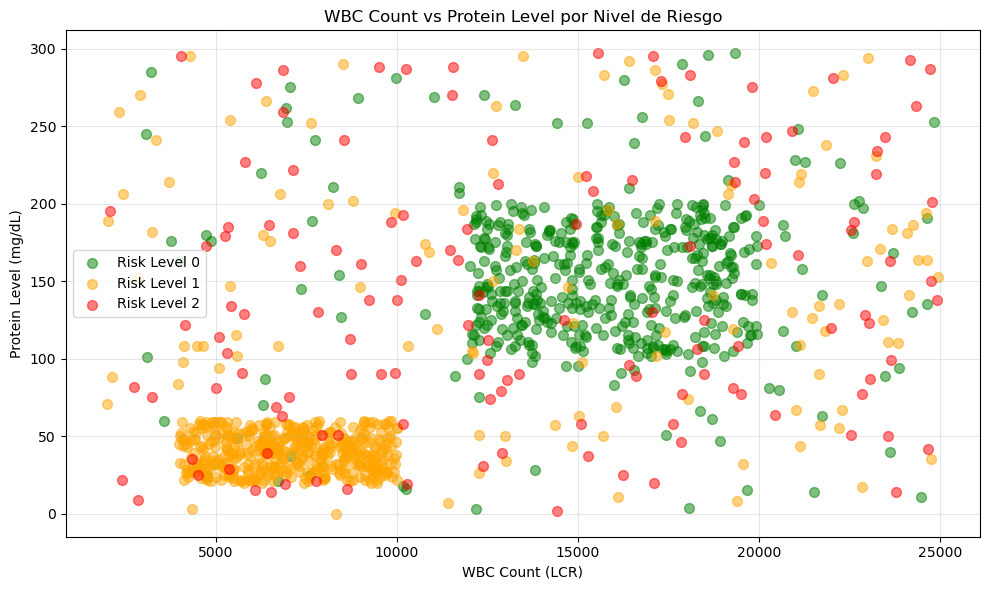

In [6]:
# Relación entre Protein_Level y WBC_Count por Risk_Level
plt.figure(figsize=(10, 6))
colors = ['green', 'orange', 'red']
for i, risk in enumerate([0, 1, 2]):  # Low=0, Moderate=1, High=2 (después de LabelEncoder)
    mask = dt['Risk_Level'] == risk
    plt.scatter(dt.loc[mask, 'WBC_Count'], dt.loc[mask, 'Protein_Level'], 
                c=colors[i], label=f'Risk Level {risk}', alpha=0.5, s=50)

plt.xlabel('WBC Count (LCR)')
plt.ylabel('Protein Level (mg/dL)')
plt.title('WBC Count vs Protein Level por Nivel de Riesgo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()